<a href="https://colab.research.google.com/github/Sarah-0405/Cold_Spots_Bayern/blob/main/Vergleich_2024_mit_Gesamtzeitraum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- Geodataframe für LST 2024 erstellen
- KNN-Matrix für alle Städte
- GI* Analyse und Cold-Spot Klassifizierung für alle Städte
- Visualisierung und Vergleich mit Zeitraum 2019-2024

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import geopandas as gpd

Geodataframe aus "all_cities_summer_avg_lst_per_pixel_allyears.geojson" enthält Pixel-Durchschnitt der Szenen für jedes Jahr, daraus kann also einfach 2024 gefiltert werden

In [ ]:
all_cities_summer_avg_lst_per_pixel = gpd.read_file("/content/drive/MyDrive/Cold Spots Bayern/all_cities_summer_avg_lst_per_pixel_allyears.geojson")
display(all_cities_summer_avg_lst_per_pixel.head())

,longitude,latitude,year,city,avg_summer_LST_Celsius,geometry
0,9.080523,50.007251,2019,Aschaffenburg,32.516656,POINT (9.08052 50.00725)
1,9.080524,50.007521,2019,Aschaffenburg,32.417533,POINT (9.08052 50.00752)
2,9.080524,50.007791,2019,Aschaffenburg,32.320120,POINT (9.08052 50.00779)
3,9.080941,50.006711,2019,Aschaffenburg,32.817441,POINT (9.08094 50.00671)
4,9.080941,50.006981,2019,Aschaffenburg,32.648249,POINT (9.08094 50.00698)


# Geodataframe für 2024 erstellen

In [ ]:
# Filter the geodataframe for the year 2024
gdf_2024 = all_cities_summer_avg_lst_per_pixel[all_cities_summer_avg_lst_per_pixel['year'] == 2024].copy()

print(gdf_2024.head())

        longitude   latitude  year           city  avg_summer_LST_Celsius  \
292706   9.080523  50.007251  2024  Aschaffenburg               15.599166   
292707   9.080524  50.007521  2024  Aschaffenburg               15.445355   
292708   9.080524  50.007791  2024  Aschaffenburg               15.342814   
292709   9.080941  50.006711  2024  Aschaffenburg               16.146049   
292710   9.080941  50.006981  2024  Aschaffenburg               15.848681   

                        geometry  
292706  POINT (9.08052 50.00725)  
292707  POINT (9.08052 50.00752)  
292708  POINT (9.08052 50.00779)  
292709  POINT (9.08094 50.00671)  
292710  POINT (9.08094 50.00698)  


## Geodataframe 2024 speichern

In [ ]:
# Define the output path in Google Drive
output_path = "/content/drive/MyDrive/Cold Spots Bayern/lst_2024_allcities.geojson"

# Save the geodataframe to a GeoJSON file
gdf_2024.to_file(output_path, driver='GeoJSON')

print(f"Geodataframe 'gdf_2024' erfolgreich gespeichert als: {output_path}")

Geodataframe 'gdf_2024' erfolgreich gespeichert als: /content/drive/MyDrive/Cold Spots Bayern/lst_2024_allcities.geojson


## Geodataframe laden

In [ ]:
# Define the path to the GeoJSON file in Google Drive
input_path = "/content/drive/MyDrive/Cold Spots Bayern/lst_2024_allcities.geojson"

# Read the GeoJSON file into a geodataframe
loaded_gdf_2024 = gpd.read_file(input_path)

# Display the first few rows of the loaded geodataframe to verify
display(loaded_gdf_2024.head())

,longitude,latitude,year,city,avg_summer_LST_Celsius,geometry
0,9.080523,50.007251,2024,Aschaffenburg,15.599166,POINT (9.08052 50.00725)
1,9.080524,50.007521,2024,Aschaffenburg,15.445355,POINT (9.08052 50.00752)
2,9.080524,50.007791,2024,Aschaffenburg,15.342814,POINT (9.08052 50.00779)
3,9.080941,50.006711,2024,Aschaffenburg,16.146049,POINT (9.08094 50.00671)
4,9.080941,50.006981,2024,Aschaffenburg,15.848681,POINT (9.08094 50.00698)


ab hier löschen?

# KNN-Matrix 2024 erstellen

In [ ]:
import libpysal as lps
import pandas as pd

# Initialize a dictionary to store the KNN weights matrices for each city
knn_weights_matrices = {}

# Get the unique cities from the geodataframe
cities = gdf_2024['city'].unique()

# Iterate through each city and create the KNN weights matrix
for city in cities:
    print(f"Creating KNN weights matrix for {city}...")
    # Filter the geodataframe for the current city
    gdf_city = gdf_2024[gdf_2024['city'] == city].copy()

    # Create the KNN weights matrix with k=12
    # Ensure that the number of neighbors (k) is not greater than the number of observations in the city's geodataframe
    k_neighbors = min(12, len(gdf_city) - 1) if len(gdf_city) > 1 else 0

    if k_neighbors > 0:
        wq = lps.weights.KNN.from_dataframe(gdf_city, k=k_neighbors)
        knn_weights_matrices[city] = wq
        print(f"KNN weights matrix created for {city} with k={k_neighbors}.")
    else:
        print(f"Skipping KNN weights matrix creation for {city} as it has {len(gdf_city)} observation(s).")


# You can now access the weights matrix for each city using the dictionary
# For example, to access the weights matrix for Munich:
# munich_wq = knn_weights_matrices['Munich']

# To store the weights matrices, you could iterate through the dictionary and save each one
# For example, saving to a file (e.g., using pickle or saving to a sparse matrix format if needed)
# import pickle
# with open('knn_weights_matrices.pkl', 'wb') as f:
#     pickle.dump(knn_weights_matrices, f)

print("\nKNN weights matrices created for all cities and stored in the 'knn_weights_matrices' dictionary.")

Creating KNN weights matrix for Aschaffenburg...
KNN weights matrix created for Aschaffenburg with k=12.
Creating KNN weights matrix for Augsburg...
KNN weights matrix created for Augsburg with k=12.
Creating KNN weights matrix for Bamberg...
KNN weights matrix created for Bamberg with k=12.
Creating KNN weights matrix for Bayreuth...


/usr/local/lib/python3.11/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


KNN weights matrix created for Bayreuth with k=12.
Creating KNN weights matrix for Erlangen...


/usr/local/lib/python3.11/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


KNN weights matrix created for Erlangen with k=12.
Creating KNN weights matrix for Fürth...
KNN weights matrix created for Fürth with k=12.
Creating KNN weights matrix for Ingolstadt...
KNN weights matrix created for Ingolstadt with k=12.
Creating KNN weights matrix for Kempten (Allgäu)...


...

KNN weights matrix created for Kempten (Allgäu) with k=12.
Creating KNN weights matrix for Landshut...
KNN weights matrix created for Landshut with k=12.
Creating KNN weights matrix for Munich...


/usr/local/lib/python3.11/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


KNN weights matrix created for Munich with k=12.
Creating KNN weights matrix for Nuremberg...


/usr/local/lib/python3.11/dist-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


KNN weights matrix created for Nuremberg with k=12.
Creating KNN weights matrix for Passau...
KNN weights matrix created for Passau with k=12.
Creating KNN weights matrix for Regensburg...
KNN weights matrix created for Regensburg with k=12.
Creating KNN weights matrix for Rosenheim...
KNN weights matrix created for Rosenheim with k=12.
Creating KNN weights matrix for Schweinfurt...
KNN weights matrix created for Schweinfurt with k=12.
Creating KNN weights matrix for Würzburg...
KNN weights matrix created for Würzburg with k=12.

KNN weights matrices created for all cities and stored in the 'knn_weights_matrices' dictionary.


## KNN-Matrix speichern

In [ ]:
import os
import libpysal as ps # libpysal wird zum Speichern benötigt

# Definieren Sie den Ordner, in dem die Gewichtsmatrizen gespeichert werden sollen
# Passen Sie diesen Pfad bei Bedarf an, idealerweise in Ihrem Google Drive
output_weights_folder = "/content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/" # Adjusted folder name
os.makedirs(output_weights_folder, exist_ok=True) # Erstellt den Ordner, falls er nicht existiert

print(f"Speichere KNN-Gewichtsmatrizen im Ordner: {output_weights_folder}")

# Schleife über das Dictionary und speichern Sie jede Gewichtsmatrix
for city, w_matrix in knn_weights_matrices.items(): # Using the correct dictionary variable name
    if w_matrix is not None:
        # Erstellen Sie einen Dateinamen basierend auf dem Stadtnamen
        # Verwenden Sie ein Format, das von libpysal unterstützt wird, z.B. .gal oder .gwt
        # Für KNN ist .gwt (General Weights format) oft passend, aber .gal funktioniert auch oft.
        # Wir verwenden hier .gal als Beispiel.
        file_name = f"{city.replace(' ', '_')}_knn_k12.gal" # Adjusted filename
        file_path = os.path.join(output_weights_folder, file_name)

        try:
            # Speichern Sie die Gewichtsmatrix mit libpysal.io.open()
            # Verwenden Sie nicht den context manager (with), da GalIO ihn nicht unterstützt
            f = ps.io.open(file_path, mode='w')
            f.write(w_matrix)
            f.close() # Datei explizit schließen

            print(f"  Gewichtsmatrix für {city} gespeichert unter: {file_path}")
        except Exception as e:
            print(f"  Fehler beim Speichern der Gewichtsmatrix für {city}: {e}")
    else:
        print(f"  Keine Gewichtsmatrix für {city} verfügbar zum Speichern.")

print("\nSpeichern der KNN-Gewichtsmatrizen abgeschlossen.")

Speichere KNN-Gewichtsmatrizen im Ordner: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/
  Gewichtsmatrix für Aschaffenburg gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Aschaffenburg_knn_k12.gal
  Gewichtsmatrix für Augsburg gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Augsburg_knn_k12.gal
  Gewichtsmatrix für Bamberg gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Bamberg_knn_k12.gal
  Gewichtsmatrix für Bayreuth gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Bayreuth_knn_k12.gal
  Gewichtsmatrix für Erlangen gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Erlangen_knn_k12.gal
  Gewichtsmatrix für Fürth gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Fürth_knn_k12.gal
  Gewichtsmatrix für Ingolstadt gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/Ingolstadt_knn_k12.g

## KNN Matrix laden

In [ ]:
import os
import libpysal as ps

# Define the directory in Google Drive where the weights matrices are saved
input_dir = "/content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/"

# Initialize a dictionary to store the loaded KNN weights matrices
loaded_knn_weights_matrices = {}

print(f"Lade KNN-Gewichtsmatrizen aus dem Ordner: {input_dir}")

# Iterate through the files in the directory
for filename in os.listdir(input_dir):
    if filename.endswith(".gal"):
        city_name = filename.replace("_knn_k12.gal", "").replace("_", " ") # Extract city name from filename
        file_path = os.path.join(input_dir, filename)

        try:
            # Open and read the weights matrix using libpysal.io.open()
            f = ps.io.open(file_path, mode='r')
            w_matrix = f.read()
            f.close() # Close the file

            loaded_knn_weights_matrices[city_name] = w_matrix
            print(f"  Gewichtsmatrix für {city_name} geladen.")
        except Exception as e:
            print(f"  Fehler beim Laden der Gewichtsmatrix aus {filename}: {e}")

print("\nLaden der KNN-Gewichtsmatrizen abgeschlossen.")

# You can now access the loaded weights matrices using the 'loaded_knn_weights_matrices' dictionary
# For example: munich_wq = loaded_knn_weights_matrices['Munich']

Lade KNN-Gewichtsmatrizen aus dem Ordner: /content/drive/MyDrive/Cold Spots Bayern/knn_weights_2024/
  Gewichtsmatrix für Aschaffenburg geladen.
  Gewichtsmatrix für Augsburg geladen.
  Gewichtsmatrix für Bamberg geladen.


/usr/local/lib/python3.11/dist-packages/libpysal/io/iohandlers/gal.py:185: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  w = W(neighbors, id_order=ids)


  Gewichtsmatrix für Bayreuth geladen.


/usr/local/lib/python3.11/dist-packages/libpysal/io/iohandlers/gal.py:185: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
  w = W(neighbors, id_order=ids)


  Gewichtsmatrix für Erlangen geladen.
  Gewichtsmatrix für Fürth geladen.
  Gewichtsmatrix für Ingolstadt geladen.


/usr/local/lib/python3.11/dist-packages/libpysal/io/iohandlers/gal.py:185: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  w = W(neighbors, id_order=ids)


  Gewichtsmatrix für Kempten (Allgäu) geladen.
  Gewichtsmatrix für Landshut geladen.
  Gewichtsmatrix für Munich geladen.
  Gewichtsmatrix für Nuremberg geladen.
  Gewichtsmatrix für Passau geladen.
  Gewichtsmatrix für Regensburg geladen.
  Gewichtsmatrix für Rosenheim geladen.
  Gewichtsmatrix für Schweinfurt geladen.
  Gewichtsmatrix für Würzburg geladen.

Laden der KNN-Gewichtsmatrizen abgeschlossen.


# Gi* 2024

In [ ]:
!pip install esda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 3.1 MB/s eta 0:00:00


In [ ]:
from esda.getisord import G_Local
import os

# Define the output folder for Gi* results in Google Drive
output_gi_folder = "/content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/"
os.makedirs(output_gi_folder, exist_ok=True) # Create the folder if it doesn't exist

print(f"Berechne Gi* und speichere Ergebnisse im Ordner: {output_gi_folder}")

# Define the function for calculating hotspots (Gi*)
def calculate_hotspots(gdf, w):
    gdf = gdf.copy()
    # Ensure the 'avg_summer_LST_Celsius' column exists in the geodataframe
    if "avg_summer_LST_Celsius" not in gdf.columns:
        print("Error: 'avg_summer_LST_Celsius' column not found in the geodataframe.")
        return None

    # Ensure the weights matrix is compatible with the geodataframe
    if w.n != len(gdf):
        print(f"Error: Weights matrix size ({w.n}) does not match geodataframe size ({len(gdf)}). Skipping Gi* calculation for this city.")
        return gdf

    g = G_Local(gdf["avg_summer_LST_Celsius"], w)
    gdf["Gi*"] = g.Zs
    return gdf

# Iterate through each city and perform the Gi* analysis
for city, w in loaded_knn_weights_matrices.items(): # Use loaded_knn_weights_matrices
    print(f"Calculating Gi* for {city}...")
    # Get the geodataframe for the current city from the loaded_gdf_2024
    gdf_city = loaded_gdf_2024[loaded_gdf_2024['city'] == city].copy() # Use loaded_gdf_2024

    # Calculate hotspots (Gi*) for the current city
    gdf_city_with_gi = calculate_hotspots(gdf_city, w)

    if gdf_city_with_gi is not None:
        # Define the output path for the current city's Gi* results
        file_name = f"{city.replace(' ', '_')}_gi_results_2024.geojson"
        file_path = os.path.join(output_gi_folder, file_name)

        try:
            # Save the geodataframe with Gi* results to a GeoJSON file
            gdf_city_with_gi.to_file(file_path, driver='GeoJSON')
            print(f"  Gi* Ergebnisse für {city} gespeichert unter: {file_path}")
        except Exception as e:
            print(f"  Fehler beim Speichern der Gi* Ergebnisse für {city}: {e}")

    else:
        print(f"Gi* calculation skipped for {city} due to errors.")


print("\nGi* Analyse abgeschlossen und Ergebnisse gespeichert.")

Berechne Gi* und speichere Ergebnisse im Ordner: /content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/
Calculating Gi* for Aschaffenburg...
  Gi* Ergebnisse für Aschaffenburg gespeichert unter: /content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/Aschaffenburg_gi_results_2024.geojson
Calculating Gi* for Augsburg...


ab abgestürzter Stadt weiter

In [ ]:
from esda.getisord import G_Local
import os

# Define the output folder for Gi* results in Google Drive
output_gi_folder = "/content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/"
os.makedirs(output_gi_folder, exist_ok=True) # Create the folder if it doesn't exist

print(f"Berechne Gi* und speichere Ergebnisse im Ordner: {output_gi_folder}")

# Define the function for calculating hotspots (Gi*)
def calculate_hotspots(gdf, w):
    gdf = gdf.copy()
    # Ensure the 'avg_summer_LST_Celsius' column exists in the geodataframe
    if "avg_summer_LST_Celsius" not in gdf.columns:
        print("Error: 'avg_summer_LST_Celsius' column not found in the geodataframe.")
        return None

    # Ensure the weights matrix is compatible with the geodataframe
    if w.n != len(gdf):
        print(f"Error: Weights matrix size ({w.n}) does not match geodataframe size ({len(gdf)}). Skipping Gi* calculation for this city.")
        return gdf

    g = G_Local(gdf["avg_summer_LST_Celsius"], w)
    gdf["Gi*"] = g.Zs
    return gdf

# Get the list of cities from the loaded geodataframe (loaded_gdf_2024) and sort them
cities = sorted(loaded_gdf_2024['city'].unique())

# Define the starting city for processing (change this to your desired city)
start_city = "Munich"  # Example: Start processing from Passau

# Find the index of the starting city
try:
    start_index = cities.index(start_city)
except ValueError:
    print(f"Error: '{start_city}' not found in the list of cities. Processing all cities from the beginning.")
    start_index = 0

# Get the list of cities to process from the starting city onwards
cities_to_process = cities[start_index:]

print(f"\n🚀 Starte Berechnung ab: {start_city}")

# Iterate through the cities to process and perform the Gi* analysis
for city in cities_to_process:
    # Check if the weights matrix for the current city exists
    if city not in loaded_knn_weights_matrices: # Use loaded_knn_weights_matrices
        print(f"⚠️  Kein Gewicht für {city} gefunden — überspringe.")
        continue

    print(f"\n✨ Bearbeite {city}...")

    # Get the geodataframe for the current city from the loaded_gdf_2024
    gdf_city = loaded_gdf_2024[loaded_gdf_2024['city'] == city].copy() # Use loaded_gdf_2024

    # Get the weights matrix for the current city
    w = loaded_knn_weights_matrices[city] # Use loaded_knn_weights_matrices

    # Calculate hotspots (Gi*) for the current city
    result_gdf = calculate_hotspots(gdf_city, w)

    if result_gdf is not None:
        # Define the output path for the current city's Gi* results
        file_name = f"{city.replace(' ', '_')}_gi_results_2024.geojson"
        file_path = os.path.join(output_gi_folder, file_name)

        try:
            # Save the geodataframe with Gi* results to a GeoJSON file
            result_gdf.to_file(file_path, driver='GeoJSON')
            print(f"✅ Ergebnis für {city} gespeichert: {file_path}")
            # Optional: Free up memory after saving
            del result_gdf
            del gdf_city
        except Exception as e:
            print(f"  Fehler beim Speichern der Gi* Ergebnisse für {city}: {e}")

    else:
        print(f"Gi* calculation skipped for {city} due to errors.")


print("\nGi* Analyse abgeschlossen und Ergebnisse gespeichert.")

Berechne Gi* und speichere Ergebnisse im Ordner: /content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/

🚀 Starte Berechnung ab: Munich

✨ Bearbeite Munich...


abgestürzt bei München

In [ ]:
from esda.getisord import G_Local
import os

# Define the output folder for Gi* results in Google Drive
output_gi_folder = "/content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/"
os.makedirs(output_gi_folder, exist_ok=True) # Create the folder if it doesn't exist

print(f"Berechne Gi* und speichere Ergebnisse im Ordner: {output_gi_folder}")

# Define the function for calculating hotspots (Gi*)
def calculate_hotspots(gdf, w):
    gdf = gdf.copy()
    # Ensure the 'avg_summer_LST_Celsius' column exists in the geodataframe
    if "avg_summer_LST_Celsius" not in gdf.columns:
        print("Error: 'avg_summer_LST_Celsius' column not found in the geodataframe.")
        return None

    # Ensure the weights matrix is compatible with the geodataframe
    if w.n != len(gdf):
        print(f"Error: Weights matrix size ({w.n}) does not match geodataframe size ({len(gdf)}). Skipping Gi* calculation for this city.")
        return gdf

    g = G_Local(gdf["avg_summer_LST_Celsius"], w)
    gdf["Gi*"] = g.Zs
    return gdf

# Define the city to process
city_to_process = "Kempten (Allgäu)" # Changed to Kempten (Allgäu)

print(f"\n🚀 Starte Berechnung für die ausgewählte Stadt: {city_to_process}")

# Need to handle the umlaut in Fürth and Kempten (Allgäu) when checking for the weight matrix key
city_key_in_weights = city_to_process
if city_to_process == "Fürth":
    # Check for both "Fürth" and "Fürth" (with combining diaeresis) in the weights dictionary keys
    if "Fürth" in loaded_knn_weights_matrices:
        city_key_in_weights = "Fürth"
    elif "Fürth" in loaded_knn_weights_matrices:
        city_key_in_weights = "Fürth"
    else:
        print(f"⚠️  Kein Gewicht für {city_to_process} gefunden — überspringe.")
        city_key_in_weights = None # Set to None to skip processing

elif city_to_process == "Kempten (Allgäu)":
    if "Kempten (Allgäu)" in loaded_knn_weights_matrices:
        city_key_in_weights = "Kempten (Allgäu)"
    elif "Kempten (Allgäu)" in loaded_knn_weights_matrices:
        city_key_in_weights = "Kempten (Allgäu)"
    else:
        print(f"⚠️  Kein Gewicht für {city_to_process} gefunden — überspringe.")
        city_key_in_weights = None # Set to None to skip processing
elif city_to_process == "Würzburg":
     if "Würzburg" in loaded_knn_weights_matrices:
         city_key_in_weights = "Würzburg"
     elif "Würzburg" in loaded_knn_weights_matrices:
         city_key_in_weights = "Würzburg"
     else:
        print(f"⚠️  Kein Gewicht für {city_to_process} gefunden — überspringe.")
        city_key_in_weights = None # Set to None to skip processing


if city_key_in_weights is not None:
    print(f"\n✨ Bearbeite {city_to_process}...")

    # Get the geodataframe for the current city from the loaded_gdf_2024
    # Need to handle the umlaut in Fürth if the key in loaded_gdf_2024
    # uses a different representation
    city_key_in_gdf = city_to_process
    if city_to_process == "Fürth":
        # Check for both "Fürth" and "Fürth" (with combining diaeresis)
        if "Fürth" in loaded_gdf_2024['city'].unique():
            city_key_in_gdf = "Fürth"
        elif "Fürth" in loaded_gdf_2024['city'].unique():
            city_key_in_gdf = "Fürth"
        else:
            print(f"Error: '{city_to_process}' not found in the loaded geodataframe.")
            city_key_in_gdf = None # Set to None to skip processing

    elif city_to_process == "Kempten (Allgäu)":
         if "Kempten (Allgäu)" in loaded_gdf_2024['city'].unique():
            city_key_in_gdf = "Kempten (Allgäu)"
         elif "Kempten (Allgäu)" in loaded_gdf_2024['city'].unique():
            city_key_in_gdf = "Kempten (Allgäu)"
         else:
            print(f"Error: '{city_to_process}' not found in the loaded geodataframe.")
            city_key_in_gdf = None # Set to None to skip processing
    elif city_to_process == "Würzburg":
         if "Würzburg" in loaded_gdf_2024['city'].unique():
             city_key_in_gdf = "Würzburg"
         elif "Würzburg" in loaded_gdf_2024['city'].unique():
             city_key_in_gdf = "Würzburg"
         else:
            print(f"Error: '{city_to_process}' not found in the loaded geodataframe.")
            city_key_in_gdf = None # Set to None to skip processing


    if city_key_in_gdf is not None:
        gdf_city = loaded_gdf_2024[loaded_gdf_2024['city'] == city_key_in_gdf].copy()

        # Get the weights matrix for the current city
        w = loaded_knn_weights_matrices[city_key_in_weights]

        # Calculate hotspots (Gi*) for the current city
        result_gdf = calculate_hotspots(gdf_city, w)

        if result_gdf is not None:
            # Define the output path for the current city's Gi* results
            file_name = f"{city_to_process.replace(' ', '_').replace('(', '').replace(')', '').replace('ä', 'ae').replace('ö', 'oe').replace('ü', 'ue').replace('Ü', 'Ue').replace('ä', 'ae')}_gi_results_2024.geojson"
            file_path = os.path.join(output_gi_folder, file_name)

            try:
                # Save the geodataframe with Gi* results to a GeoJSON file
                result_gdf.to_file(file_path, driver='GeoJSON')
                print(f"✅ Ergebnis für {city_to_process} gespeichert: {file_path}")
                # Optional: Free up memory after saving
                del result_gdf
                del gdf_city
            except Exception as e:
                print(f"  Fehler beim Speichern der Gi* Ergebnisse für {city_to_process}: {e}")

        else:
            print(f"Gi* calculation skipped for {city_to_process} due to errors.")

    else:
        print(f"Gi* calculation skipped for {city_to_process} as geodataframe not found.")


print("\nGi* Analyse für ausgewählte Stadt abgeschlossen und Ergebnisse gespeichert.")

Berechne Gi* und speichere Ergebnisse im Ordner: /content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/

🚀 Starte Berechnung für die ausgewählte Stadt: Kempten (Allgäu)

✨ Bearbeite Kempten (Allgäu)...
✅ Ergebnis für Kempten (Allgäu) gespeichert: /content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/Kempten_Allgaeu_gi_results_2024.geojson

Gi* Analyse für ausgewählte Stadt abgeschlossen und Ergebnisse gespeichert.


## Gi* Ergebnisse aus drive laden

In [ ]:
# Define the directory in Google Drive where the Gi* results are saved
input_gi_dir = "/content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/"

# Initialize an empty list to store individual geodataframes
gi_gdfs = []

print(f"Lade Gi* Ergebnisse aus dem Ordner: {input_gi_dir}")

# Iterate through the files in the directory
for filename in os.listdir(input_gi_dir):
    if filename.endswith(".geojson"):
        file_path = os.path.join(input_gi_dir, filename)
        try:
            # Read the GeoJSON file into a geodataframe
            gdf = gpd.read_file(file_path)
            gi_gdfs.append(gdf)
            print(f"  Geladen: {filename}")
        except Exception as e:
            print(f"  Fehler beim Laden von {filename}: {e}")

Lade Gi* Ergebnisse aus dem Ordner: /content/drive/MyDrive/Cold Spots Bayern/gi_results_2024/
  Geladen: Aschaffenburg_gi_results_2024.geojson
  Geladen: Augsburg_gi_results_2024.geojson
  Geladen: Bamberg_gi_results_2024.geojson
  Geladen: Bayreuth_gi_results_2024.geojson
  Geladen: Erlangen_gi_results_2024.geojson
  Geladen: Ingolstadt_gi_results_2024.geojson
  Geladen: Landshut_gi_results_2024.geojson
  Geladen: Nuremberg_gi_results_2024.geojson
  Geladen: Passau_gi_results_2024.geojson
  Geladen: Regensburg_gi_results_2024.geojson
  Geladen: Rosenheim_gi_results_2024.geojson
  Geladen: Schweinfurt_gi_results_2024.geojson
  Geladen: Fuerth_gi_results_2024.geojson
  Geladen: Wuerzburg_gi_results_2024.geojson
  Geladen: Kempten_Allgaeu_gi_results_2024.geojson


AttributeError: module 'geopandas' has no attribute 'concat'

## Gi* Ergebnisse nach Cold Spots klassifizieren

In [ ]:
# Definieren Sie die zu verwendenden Schwellenwerte für die Signifikanz (Z-Werte)
# Gängige Schwellenwerte für z-Werte:
# ~1.65 für 90% Konfidenz (p<0.10)
# ~1.96 für 95% Konfidenz (p<0.05)
# ~2.58 für 99% Konfidenz (p<0.01)
z_score_thresholds = {
    'p010': 1.645, # ~90% Konfidenz
    'p005': 1.96,  # ~95% Konfidenz
    'p001': 2.576  # ~99% Konfidenz
}

# Stellen Sie sicher, dass die Liste der individuellen Geodataframes existiert und nicht leer ist
if 'gi_gdfs' in locals() and gi_gdfs:

    print(f"Klassifiziere Gi* Ergebnisse für jede Stadt einzeln basierend auf Z-Werten und Schwellenwerten: {z_score_thresholds.keys()}...")

    # Initialisieren Sie ein Dictionary, um die klassifizierten Geodataframes für jede Stadt zu speichern
    classified_gi_gdfs = {}

    # Iterieren Sie durch die individuellen Geodataframes
    for gdf in gi_gdfs:
        if 'Gi*' in gdf.columns and 'city' in gdf.columns and not gdf.empty:
            # Holen Sie den Stadtnamen (wir gehen davon aus, dass jede gdf nur Daten für eine Stadt enthält)
            city_name = gdf['city'].iloc[0]
            print(f"\nKlassifiziere Ergebnisse für {city_name}...")

            # Erstellen Sie eine Kopie, um das ursprüngliche Geodataframe nicht zu ändern
            gdf_classified = gdf.copy()

            # Iterieren Sie über die definierten Z-Wert-Schwellenwerte
            for label, threshold in z_score_thresholds.items():
                # Definieren Sie den Spaltennamen für die Klassifizierung bei diesem Schwellenwert
                sig_col_name = f'Gi_Star_sig_{label}'

                # Setzen Sie einen Standardwert für diese Signifikanzstufe
                gdf_classified[sig_col_name] = 'Nicht signifikant'

                # Klassifizieren Sie Hot Spots: Gi* (Z-Wert) > threshold
                gdf_classified.loc[
                    gdf_classified['Gi*'] > threshold,
                    sig_col_name
                ] = f'Hot Spot (z>{threshold:.3f})'

                # Klassifizieren Sie Cold Spots: Gi* (Z-Wert) < -threshold
                gdf_classified.loc[
                    gdf_classified['Gi*'] < -threshold,
                    sig_col_name
                ] = f'Cold Spot (z<{-threshold:.3f})'

            # Speichern Sie das klassifizierte Geodataframe im Dictionary
            classified_gi_gdfs[city_name] = gdf_classified
            print(f"Klassifizierung für {city_name} abgeschlossen.")

            # Optional: Zeigen Sie die Verteilung der Klassifizierungen für die aktuelle Stadt
            print(f"  Verteilung der Klassifizierungen für {city_name}:")
            for label in z_score_thresholds.keys():
                 sig_col_name = f'Gi_Star_sig_{label}'
                 print(f"    {label}:")
                 print(gdf_classified[sig_col_name].value_counts().to_string())


        elif not gdf.empty:
             # This case handles a gdf that is not empty but is missing 'Gi*' or 'city' column
             print(f"\nÜberspringe Klassifizierung für ein Geodataframe, dem die Spalte 'Gi*' oder 'city' fehlt.")
        else:
            # This case handles an empty gdf
            print("\nÜberspringe Klassifizierung für ein leeres Geodataframe.")


    print("\nKlassifizierung der Gi* Ergebnisse für alle individuellen Städte abgeschlossen.")

    # Das Dictionary 'classified_gi_gdfs' enthält nun die klassifizierten Geodataframes für jede Stadt.

else:
    print("Die Liste 'gi_gdfs' wurde nicht gefunden oder ist leer. Bitte stellen Sie sicher, dass der vorherige Schritt zum Laden der Daten erfolgreich war.")

Klassifiziere Gi* Ergebnisse für jede Stadt einzeln basierend auf Z-Werten und Schwellenwerten: dict_keys(['p010', 'p005', 'p001'])...

Klassifiziere Ergebnisse für Aschaffenburg...
Klassifizierung für Aschaffenburg abgeschlossen.
  Verteilung der Klassifizierungen für Aschaffenburg:
    p010:
Gi_Star_sig_p010
Nicht signifikant       61253
Cold Spot (z<-1.645)     5200
Hot Spot (z>1.645)       2893
    p005:
Gi_Star_sig_p005
Nicht signifikant       65435
Cold Spot (z<-1.960)     2973
Hot Spot (z>1.960)        938
    p001:
Gi_Star_sig_p001
Nicht signifikant       69156
Hot Spot (z>2.576)        117
Cold Spot (z<-2.576)       73

Klassifiziere Ergebnisse für Augsburg...
Klassifizierung für Augsburg abgeschlossen.
  Verteilung der Klassifizierungen für Augsburg:
    p010:
Gi_Star_sig_p010
Nicht signifikant       155438
Hot Spot (z>1.645)        7601
Cold Spot (z<-1.645)       981
    p005:
Gi_Star_sig_p005
Nicht signifikant       159739
Hot Spot (z>1.960)        4080
Cold Spot (z<-1.960)

## Cold Spot Ergebnisse speichern (p<0,10 und p<0,05)

In [ ]:
import os

# Define the output base directory in Google Drive
output_base_dir = "/content/drive/MyDrive/Cold Spots Bayern/"

# Define the output folders for the different significance levels
output_folder_p005 = os.path.join(output_base_dir, "cold_spots_2024_p005")
output_folder_p010 = os.path.join(output_base_dir, "cold_spots_2024_p010")

# Create the output folders if they don't exist
os.makedirs(output_folder_p005, exist_ok=True)
os.makedirs(output_folder_p010, exist_ok=True)

print(f"Speichere Cold Spots (p<0.05) im Ordner: {output_folder_p005}")
print(f"Speichere Cold Spots (p<0.10) im Ordner: {output_folder_p010}")


# Stellen Sie sicher, dass das Dictionary mit den klassifizierten Geodataframes existiert und nicht leer ist
if 'classified_gi_gdfs' in locals() and classified_gi_gdfs:

    print("\nFiltere Cold Spots und speichere Ergebnisse pro Stadt...")

    # Iterieren Sie durch das Dictionary der klassifizierten Geodataframes pro Stadt
    for city_name, gdf_classified in classified_gi_gdfs.items():

        if not gdf_classified.empty:
            print(f"\nBearbeite Stadt: {city_name}")

            # Filtern Sie Cold Spots mit p<0.05 (entspricht Gi_Star_sig_p005 == 'Cold Spot (z<-1.960)')
            cold_spots_p005 = gdf_classified[gdf_classified['Gi_Star_sig_p005'] == 'Cold Spot (z<-1.960)'].copy()

            # Filtern Sie Cold Spots mit p<0.10 (entspricht Gi_Star_sig_p010 == 'Cold Spot (z<-1.645)')
            cold_spots_p010 = gdf_classified[gdf_classified['Gi_Star_sig_p010'] == 'Cold Spot (z<-1.645)'].copy()


            # Speichern Sie die Cold Spots mit p<0.05
            if not cold_spots_p005.empty:
                file_name_p005 = f"{city_name.replace(' ', '_').replace('(', '').replace(')', '').replace('ä', 'ae').replace('ö', 'oe').replace('ü', 'ue')}_cold_spots_2024_p005.geojson"
                file_path_p005 = os.path.join(output_folder_p005, file_name_p005)
                try:
                    cold_spots_p005.to_file(file_path_p005, driver='GeoJSON')
                    print(f"  {len(cold_spots_p005)} Cold Spots (p<0.05) für {city_name} gespeichert: {file_path_p005}")
                except Exception as e:
                    print(f"  Fehler beim Speichern der Cold Spots (p<0.05) für {city_name}: {e}")
            else:
                print(f"  Keine Cold Spots (p<0.05) für {city_name} gefunden.")

            # Speichern Sie die Cold Spots mit p<0.10
            if not cold_spots_p010.empty:
                file_name_p010 = f"{city_name.replace(' ', '_').replace('(', '').replace(')', '').replace('ä', 'ae').replace('ö', 'oe').replace('ü', 'ue')}_cold_spots_2024_p010.geojson"
                file_path_p010 = os.path.join(output_folder_p010, file_name_p010)
                try:
                    cold_spots_p010.to_file(file_path_p010, driver='GeoJSON')
                    print(f"  {len(cold_spots_p010)} Cold Spots (p<0.10) für {city_name} gespeichert: {file_path_p010}")
                except Exception as e:
                    print(f"  Fehler beim Speichern der Cold Spots (p<0.10) für {city_name}: {e}")
            else:
                print(f"  Keine Cold Spots (p<0.10) für {city_name} gefunden.")

            # Optional: Freigabe von Speicher
            del cold_spots_p005
            del cold_spots_p010


        else:
            print(f"\nÜberspringe Stadt {city_name}: Geodataframe ist leer.")


    print("\nFiltern und Speichern der Cold Spots abgeschlossen.")

else:
    print("Das Dictionary 'classified_gi_gdfs' wurde nicht gefunden oder ist leer. Bitte stellen Sie sicher, dass der vorherige Schritt zur Klassifizierung erfolgreich war.")

Speichere Cold Spots (p<0.05) im Ordner: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p005
Speichere Cold Spots (p<0.10) im Ordner: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p010

Filtere Cold Spots und speichere Ergebnisse pro Stadt...

Bearbeite Stadt: Aschaffenburg
  2973 Cold Spots (p<0.05) für Aschaffenburg gespeichert: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p005/Aschaffenburg_cold_spots_2024_p005.geojson
  5200 Cold Spots (p<0.10) für Aschaffenburg gespeichert: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p010/Aschaffenburg_cold_spots_2024_p010.geojson

Bearbeite Stadt: Augsburg
  201 Cold Spots (p<0.05) für Augsburg gespeichert: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p005/Augsburg_cold_spots_2024_p005.geojson
  981 Cold Spots (p<0.10) für Augsburg gespeichert: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p010/Augsburg_cold_spots_2024_p010.geojson

Bearbeite Stadt: Bamberg
  195 Cold Spots (p<0

# VERGLEICH: 2024 mit 2019-2024

##laden der CS für 2024

In [ ]:
import geopandas as gpd
import os

# Define the base directory in Google Drive where the Cold Spot results are saved
input_base_dir = "/content/drive/MyDrive/Cold Spots Bayern/"

# Define the input folders for the different significance levels
input_folder_p005 = os.path.join(input_base_dir, "cold_spots_2024_p005")
input_folder_p010 = os.path.join(input_base_dir, "cold_spots_2024_p010")

# Initialize dictionaries to store the loaded Cold Spot geodataframes
loaded_cold_spots_p005 = {}
loaded_cold_spots_p010 = {}

print(f"Lade Cold Spots (p<0.05) aus dem Ordner: {input_folder_p005}")

# Load Cold Spots with p<0.05
if os.path.exists(input_folder_p005):
    for filename in os.listdir(input_folder_p005):
        if filename.endswith(".geojson"):
            file_path = os.path.join(input_folder_p005, filename)
            try:
                gdf = gpd.read_file(file_path)
                # Extract city name from filename (remove "_cold_spots_2024_p005.geojson" and replace underscores with spaces)
                city_name = filename.replace("_cold_spots_2024_p005.geojson", "").replace("_", " ")
                # Handle the umlaut and special characters in city names if necessary
                city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
                city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
                loaded_cold_spots_p005[city_name] = gdf
                print(f"  Geladen: {filename} ({city_name})")
            except Exception as e:
                print(f"  Fehler beim Laden von {filename}: {e}")
else:
    print(f"  Ordner nicht gefunden: {input_folder_p005}")


print(f"\nLade Cold Spots (p<0.10) aus dem Ordner: {input_folder_p010}")

# Load Cold Spots with p<0.10
if os.path.exists(input_folder_p010):
    for filename in os.listdir(input_folder_p010):
        if filename.endswith(".geojson"):
            file_path = os.path.join(input_folder_p010, filename)
            try:
                gdf = gpd.read_file(file_path)
                # Extract city name from filename (remove "_cold_spots_2024_p010.geojson" and replace underscores with spaces)
                city_name = filename.replace("_cold_spots_2024_p010.geojson", "").replace("_", " ")
                 # Handle the umlaut and special characters in city names if necessary
                city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
                city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
                loaded_cold_spots_p010[city_name] = gdf
                print(f"  Geladen: {filename} ({city_name})")
            except Exception as e:
                print(f"  Fehler beim Laden von {filename}: {e}")
else:
     print(f"  Ordner nicht gefunden: {input_folder_p010}")


print("\nLaden der Cold Spot Ergebnisse abgeschlossen.")

# You can now access the loaded cold spot geodataframes using the dictionaries
# For example: munich_cold_spots_p005 = loaded_cold_spots_p005['Munich']

Lade Cold Spots (p<0.05) aus dem Ordner: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_2024_p005
  Geladen: Aschaffenburg_cold_spots_2024_p005.geojson (Aschaffenburg)
  Geladen: Augsburg_cold_spots_2024_p005.geojson (Augsburg)
  Geladen: Bamberg_cold_spots_2024_p005.geojson (Bamberg)
  Geladen: Erlangen_cold_spots_2024_p005.geojson (Erlangen)
  Geladen: Ingolstadt_cold_spots_2024_p005.geojson (Ingolstadt)
  Geladen: Landshut_cold_spots_2024_p005.geojson (Landshut)
  Geladen: Nuremberg_cold_spots_2024_p005.geojson (Nuremberg)
  Geladen: Passau_cold_spots_2024_p005.geojson (Passau)
  Geladen: Regensburg_cold_spots_2024_p005.geojson (Regensburg)
  Geladen: Rosenheim_cold_spots_2024_p005.geojson (Rosenheim)
  Geladen: Schweinfurt_cold_spots_2024_p005.geojson (Schweinfurt)
  Geladen: Fuerth_cold_spots_2024_p005.geojson (Fürth)
  Geladen: Wuerzburg_cold_spots_2024_p005.geojson (Würzburg)
  Geladen: Kempten_Allgaeu_cold_spots_2024_p005.geojson (Kempten Allgäu)

Lade Cold Spots (p<0.10) 

##laden der CS für 2019-2024

In [ ]:
import geopandas as gpd
import os

# Define the base directory in Google Drive where the Cold Spot results are saved
input_base_dir = "/content/drive/MyDrive/Cold Spots Bayern/"

# Define the input folders for the different significance levels for the 2019-2024 period
input_folder_p005_2019_2024 = os.path.join(input_base_dir, "cold_spots_p005")
input_folder_p010_2019_2024 = os.path.join(input_base_dir, "cold_spots_p010")

# Initialize dictionaries to store the loaded Cold Spot geodataframes for 2019-2024
loaded_cold_spots_p005_2019_2024 = {}
loaded_cold_spots_p010_2019_2024 = {}

print(f"Lade Cold Spots (p<0.05) für 2019-2024 aus dem Ordner: {input_folder_p005_2019_2024}")

# Load Cold Spots with p<0.05 for 2019-2024
if os.path.exists(input_folder_p005_2019_2024):
    for filename in os.listdir(input_folder_p005_2019_2024):
        if filename.endswith(".geojson"):
            file_path = os.path.join(input_folder_p005_2019_2024, filename)
            try:
                gdf = gpd.read_file(file_path)
                # Extract city name from filename
                city_name = filename.replace("_cold_spots_2019-2024_p005.geojson", "").replace("_", " ")
                # Handle the umlaut and special characters in city names if necessary
                city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
                city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
                loaded_cold_spots_p005_2019_2024[city_name] = gdf
                print(f"  Geladen: {filename} ({city_name})")
            except Exception as e:
                print(f"  Fehler beim Laden von {filename}: {e}")
else:
    print(f"  Ordner nicht gefunden: {input_folder_p005_2019_2024}")


print(f"\nLade Cold Spots (p<0.10) für 2019-2024 aus dem Ordner: {input_folder_p010_2019_2024}")

# Load Cold Spots with p<0.10 for 2019-2024
if os.path.exists(input_folder_p010_2019_2024):
    for filename in os.listdir(input_folder_p010_2019_2024):
        if filename.endswith(".geojson"):
            file_path = os.path.join(input_folder_p010_2019_2024, filename)
            try:
                gdf = gpd.read_file(file_path)
                # Extract city name from filename
                city_name = filename.replace("_cold_spots_2019-2024_p010.geojson", "").replace("_", " ")
                 # Handle the umlaut and special characters in city names if necessary
                city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
                city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
                loaded_cold_spots_p010_2019_2024[city_name] = gdf
                print(f"  Geladen: {filename} ({city_name})")
            except Exception as e:
                print(f"  Fehler beim Laden von {filename}: {e}")
else:
     print(f"  Ordner nicht gefunden: {input_folder_p010_2019_2024}")


print("\nLaden der Cold Spot Ergebnisse für 2019-2024 abgeschlossen.")

# You can now access the loaded cold spot geodataframes using the dictionaries
# For example: munich_cold_spots_p005_2019_2024 = loaded_cold_spots_p005_2019_2024['Munich']

Lade Cold Spots (p<0.05) für 2019-2024 aus dem Ordner: /content/drive/MyDrive/Cold Spots Bayern/cold_spots_p005
  Geladen: Augsburg_cold_spots_p005.geojson (Augsburg cold spots p005.geojson)
  Geladen: Erlangen_cold_spots_p005.geojson (Erlangen cold spots p005.geojson)
  Geladen: Bayreuth_cold_spots_p005.geojson (Bayreuth cold spots p005.geojson)
  Geladen: Landshut_cold_spots_p005.geojson (Landshut cold spots p005.geojson)
  Geladen: Ingolstadt_cold_spots_p005.geojson (Ingolstadt cold spots p005.geojson)
  Geladen: Passau_cold_spots_p005.geojson (Passau cold spots p005.geojson)
  Geladen: Rosenheim_cold_spots_p005.geojson (Rosenheim cold spots p005.geojson)
  Geladen: Schweinfurt_cold_spots_p005.geojson (Schweinfurt cold spots p005.geojson)
  Geladen: Regensburg_cold_spots_p005.geojson (Regensburg cold spots p005.geojson)
  Geladen: Nuremberg_cold_spots_p005.geojson (Nuremberg cold spots p005.geojson)
  Geladen: Würzburg_cold_spots_p005.geojson (Würzburg cold spots p005.geojson)
  G

# Statistiken der Cold Spots in Tabellenform

## **2019-2024 Zeitraum**

In [ ]:
import pandas as pd

# Initialize a list to store the summary data for each city
cold_spot_summary_list = []

# Get the list of unique cities from the loaded data for 2019-2024
# We'll use a set to ensure unique city names after cleaning
unique_cities_2019_2024 = set()

# Iterate through the keys of both dictionaries to get all potential city names
for key in loaded_cold_spots_p005_2019_2024.keys():
    # Extract and clean city name
    city_name = key.replace("_cold_spots_2019-2024_p005.geojson", "").replace("_cold_spots_p005.geojson", "").replace("_", " ").replace(".geojson", "").replace("cold spots p005", "").strip()
    city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
    city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
    unique_cities_2019_2024.add(city_name)

for key in loaded_cold_spots_p010_2019_2024.keys():
    # Extract and clean city name
    city_name = key.replace("_cold_spots_2019-2024_p010.geojson", "").replace("_cold_spots_p010.geojson", "").replace("_", " ").replace(".geojson", "").replace("cold spots p010", "").strip()
    city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
    city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)") # Specific handling for Kempten
    unique_cities_2019_2024.add(city_name)

# Sort the unique city names
sorted_cities_2019_2024 = sorted(list(unique_cities_2019_2024))

print("Erstelle Zusammenfassungstabelle für Cold Spots 2019-2024...")

# Iterate through each unique city name to gather statistics
for city_name in sorted_cities_2019_2024:
    print(f"Verarbeite Stadt: {city_name}")

    # Find the correct keys in the dictionaries for this city name
    # This is necessary because the original keys might have variations (e.g., umlauts, suffixes)
    p005_key = None
    for key in loaded_cold_spots_p005_2019_2024.keys():
        cleaned_key_name = key.replace("_cold_spots_2019-2024_p005.geojson", "").replace("_cold_spots_p005.geojson", "").replace("_", " ").replace(".geojson", "").replace("cold spots p005", "").strip()
        cleaned_key_name = cleaned_key_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
        cleaned_key_name = cleaned_key_name.replace("Kempten Allgaeu", "Kempten (Allgäu)")
        if cleaned_key_name == city_name:
            p005_key = key
            break

    p010_key = None
    for key in loaded_cold_spots_p010_2019_2024.keys():
        cleaned_key_name = key.replace("_cold_spots_2019-2024_p010.geojson", "").replace("_cold_spots_p010.geojson", "").replace("_", " ").replace(".geojson", "").replace("cold spots p010", "").strip()
        cleaned_key_name = cleaned_key_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
        cleaned_key_name = cleaned_key_name.replace("Kempten Allgaeu", "Kempten (Allgäu)")
        if cleaned_key_name == city_name:
            p010_key = key
            break

    # Get the geodataframe for p<0.05 for the current city using the found key
    gdf_p005 = loaded_cold_spots_p005_2019_2024.get(p005_key)

    # Get the geodataframe for p<0.10 for the current city using the found key
    gdf_p010 = loaded_cold_spots_p010_2019_2024.get(p010_key)


    # Initialize statistics
    count_p005 = 0
    mean_p005 = None
    min_p005 = None
    max_p005 = None

    count_p010 = 0
    mean_p010 = None
    min_p010 = None
    max_p010 = None


    # Calculate statistics for p<0.05 if data exists
    if gdf_p005 is not None and not gdf_p005.empty and 'avg_summer_LST_Celsius' in gdf_p005.columns:
        count_p005 = len(gdf_p005)
        mean_p005 = gdf_p005['avg_summer_LST_Celsius'].mean()
        min_p005 = gdf_p005['avg_summer_LST_Celsius'].min()
        max_p005 = gdf_p005['avg_summer_LST_Celsius'].max()
        print(f"  Gefunden p<0.05 Daten. Anzahl: {count_p005}")
    else:
        print(f"  Keine oder leere p<0.05 Daten gefunden.")


    # Calculate statistics for p<0.10 if data exists
    if gdf_p010 is not None and not gdf_p010.empty and 'avg_summer_LST_Celsius' in gdf_p010.columns:
        count_p010 = len(gdf_p010)
        mean_p010 = gdf_p010['avg_summer_LST_Celsius'].mean()
        min_p010 = gdf_p010['avg_summer_LST_Celsius'].min()
        max_p010 = gdf_p010['avg_summer_LST_Celsius'].max()
        print(f"  Gefunden p<0.10 Daten. Anzahl: {count_p010}")
    else:
        print(f"  Keine oder leere p<0.10 Daten gefunden.")


    # Append the summary data to the list
    cold_spot_summary_list.append({
        'Stadt': city_name,
        'Anzahl Cold Spots (p<0.05)': count_p005,
        'Mean LST (p<0.05)': mean_p005,
        'Min LST (p<0.05)': min_p005,
        'Max LST (p<0.05)': max_p005,
        'Anzahl Cold Spots (p<0.10)': count_p010,
        'Mean LST (p<0.10)': mean_p010,
        'Min LST (p<0.10)': min_p010,
        'Max LST (p<0.10)': max_p010
    })

# Create a pandas DataFrame from the list
cold_spot_summary_df = pd.DataFrame(cold_spot_summary_list)

# Display the summary table
display(cold_spot_summary_df)

Erstelle Zusammenfassungstabelle für Cold Spots 2019-2024...
Verarbeite Stadt: Aschaffenburg
  Keine oder leere p<0.05 Daten gefunden.
  Gefunden p<0.10 Daten. Anzahl: 99
Verarbeite Stadt: Augsburg
  Gefunden p<0.05 Daten. Anzahl: 84
  Gefunden p<0.10 Daten. Anzahl: 763
Verarbeite Stadt: Bayreuth
  Gefunden p<0.05 Daten. Anzahl: 1561
  Gefunden p<0.10 Daten. Anzahl: 10700
Verarbeite Stadt: Erlangen
  Gefunden p<0.05 Daten. Anzahl: 1063
  Gefunden p<0.10 Daten. Anzahl: 5121
Verarbeite Stadt: Fürth
  Gefunden p<0.05 Daten. Anzahl: 2547
  Gefunden p<0.10 Daten. Anzahl: 3528
Verarbeite Stadt: Ingolstadt
  Gefunden p<0.05 Daten. Anzahl: 3977
  Gefunden p<0.10 Daten. Anzahl: 13852
Verarbeite Stadt: Kempten Allgäu
  Gefunden p<0.05 Daten. Anzahl: 197
  Gefunden p<0.10 Daten. Anzahl: 1003
Verarbeite Stadt: Landshut
  Gefunden p<0.05 Daten. Anzahl: 1253
  Gefunden p<0.10 Daten. Anzahl: 3837
Verarbeite Stadt: Nuremberg
  Gefunden p<0.05 Daten. Anzahl: 4749
  Gefunden p<0.10 Daten. Anzahl: 12557

,Stadt,Anzahl Cold Spots (p<0.05),Mean LST (p<0.05),Min LST (p<0.05),Max LST (p<0.05),Anzahl Cold Spots (p<0.10),Mean LST (p<0.10),Min LST (p<0.10),Max LST (p<0.10)
0,Aschaffenburg,0,NaN,NaN,NaN,99,22.957557,21.703408,24.061329
1,Augsburg,84,24.412108,22.841950,25.233384,763,25.550019,22.841950,27.048739
2,Bayreuth,1561,27.291151,24.069019,29.435311,10700,28.166964,24.069019,31.052034
3,Erlangen,1063,27.216404,23.652875,32.779843,5121,27.873911,23.057285,33.827466
4,Fürth,2547,28.055504,23.925462,29.161261,3528,28.302632,23.925462,30.711542
5,Ingolstadt,3977,24.766689,21.814835,26.884044,13852,26.159404,21.814835,28.231788
6,Kempten Allgäu,197,26.636774,24.915549,27.842172,1003,27.457572,24.639829,30.487605
7,Landshut,1253,25.700635,22.304182,29.080644,3837,26.245818,22.304182,31.288020
8,Nuremberg,4749,26.380294,22.129293,29.224219,12557,27.460764,22.129293,30.392840
9,Passau,961,21.853091,17.974405,25.545367,1773,23.174998,17.974405,27.304128


(Bamberg und Aschaffenburg hatten keine Cold Spots), München fehlt auch weil noch nicht laden konnte

##**für 2024**

In [ ]:
import pandas as pd

# Initialize a list to store the summary data for each city for 2024
cold_spot_summary_list_2024 = []

# Get the list of unique cities from the loaded 2024 data
# We'll use a set to ensure unique city names after cleaning
unique_cities_2024 = set()

# Iterate through the keys of both 2024 dictionaries to get all potential city names
for key in loaded_cold_spots_p005.keys():
    # The keys in these dictionaries are already the cleaned city names
    unique_cities_2024.add(key)

for key in loaded_cold_spots_p010.keys():
    # The keys in these dictionaries are already the cleaned city names
    unique_cities_2024.add(key)

# Sort the unique city names
sorted_cities_2024 = sorted(list(unique_cities_2024))

print("Erstelle Zusammenfassungstabelle für Cold Spots 2024...")

# Iterate through each unique city name to gather statistics for 2024
for city_name in sorted_cities_2024:
    print(f"Verarbeite Stadt: {city_name}")

    # Get the geodataframe for p<0.05 for the current city
    gdf_p005_2024 = loaded_cold_spots_p005.get(city_name)

    # Get the geodataframe for p<0.10 for the current city
    gdf_p010_2024 = loaded_cold_spots_p010.get(city_name)

    # Initialize statistics
    count_p005 = 0
    mean_p005 = None
    min_p005 = None
    max_p005 = None

    count_p010 = 0
    mean_p010 = None
    min_p010 = None
    max_p010 = None

    # Calculate statistics for p<0.05 if data exists
    if gdf_p005_2024 is not None and not gdf_p005_2024.empty and 'avg_summer_LST_Celsius' in gdf_p005_2024.columns:
        count_p005 = len(gdf_p005_2024)
        mean_p005 = gdf_p005_2024['avg_summer_LST_Celsius'].mean()
        min_p005 = gdf_p005_2024['avg_summer_LST_Celsius'].min()
        max_p005 = gdf_p005_2024['avg_summer_LST_Celsius'].max()
        print(f"  Gefunden p<0.05 Daten. Anzahl: {count_p005}")
    else:
        print(f"  Keine oder leere p<0.05 Daten gefunden.")

    # Calculate statistics for p<0.10 if data exists
    if gdf_p010_2024 is not None and not gdf_p010_2024.empty and 'avg_summer_LST_Celsius' in gdf_p010_2024.columns:
        count_p010 = len(gdf_p010_2024)
        mean_p010 = gdf_p010_2024['avg_summer_LST_Celsius'].mean()
        min_p010 = gdf_p010_2024['avg_summer_LST_Celsius'].min()
        max_p010 = gdf_p010_2024['avg_summer_LST_Celsius'].max()
        print(f"  Gefunden p<0.10 Daten. Anzahl: {count_p010}")
    else:
        print(f"  Keine oder leere p<0.10 Daten gefunden.")

    # Append the summary data to the list
    cold_spot_summary_list_2024.append({
        'Stadt': city_name,
        'Anzahl Cold Spots (p<0.05)': count_p005,
        'Mean LST (p<0.05)': mean_p005,
        'Min LST (p<0.05)': min_p005,
        'Max LST (p<0.05)': max_p005,
        'Anzahl Cold Spots (p<0.10)': count_p010,
        'Mean LST (p<0.10)': mean_p010,
        'Min LST (p<0.10)': min_p010,
        'Max LST (p<0.10)': max_p010
    })

# Create a pandas DataFrame from the list
cold_spot_summary_df_2024 = pd.DataFrame(cold_spot_summary_list_2024)

# Display the summary table for 2024
display(cold_spot_summary_df_2024)

Erstelle Zusammenfassungstabelle für Cold Spots 2024...
Verarbeite Stadt: Aschaffenburg
  Gefunden p<0.05 Daten. Anzahl: 2973
  Gefunden p<0.10 Daten. Anzahl: 5200
Verarbeite Stadt: Augsburg
  Gefunden p<0.05 Daten. Anzahl: 201
  Gefunden p<0.10 Daten. Anzahl: 981
Verarbeite Stadt: Bamberg
  Gefunden p<0.05 Daten. Anzahl: 195
  Gefunden p<0.10 Daten. Anzahl: 694
Verarbeite Stadt: Bayreuth
  Keine oder leere p<0.05 Daten gefunden.
  Gefunden p<0.10 Daten. Anzahl: 338
Verarbeite Stadt: Erlangen
  Gefunden p<0.05 Daten. Anzahl: 2085
  Gefunden p<0.10 Daten. Anzahl: 3783
Verarbeite Stadt: Fürth
  Gefunden p<0.05 Daten. Anzahl: 1080
  Gefunden p<0.10 Daten. Anzahl: 1971
Verarbeite Stadt: Ingolstadt
  Gefunden p<0.05 Daten. Anzahl: 2993
  Gefunden p<0.10 Daten. Anzahl: 5977
Verarbeite Stadt: Kempten Allgäu
  Gefunden p<0.05 Daten. Anzahl: 258
  Gefunden p<0.10 Daten. Anzahl: 1159
Verarbeite Stadt: Landshut
  Gefunden p<0.05 Daten. Anzahl: 3036
  Gefunden p<0.10 Daten. Anzahl: 4676
Verarbeite

,Stadt,Anzahl Cold Spots (p<0.05),Mean LST (p<0.05),Min LST (p<0.05),Max LST (p<0.05),Anzahl Cold Spots (p<0.10),Mean LST (p<0.10),Min LST (p<0.10),Max LST (p<0.10)
0,Aschaffenburg,2973,13.603106,10.940404,14.871127,5200,14.363660,10.940404,16.590392
1,Augsburg,201,24.714591,22.783844,25.766066,981,25.826974,22.783844,28.332999
2,Bamberg,195,25.487191,10.371304,31.421180,694,25.419108,9.516799,35.550148
3,Bayreuth,0,NaN,NaN,NaN,338,27.755172,24.530452,29.797621
4,Erlangen,2085,26.904588,21.348275,31.687786,3783,27.539621,20.909060,32.614069
5,Fürth,1080,23.749794,4.733280,38.503318,1971,24.622924,4.733280,38.503318
6,Ingolstadt,2993,24.387132,21.707167,27.015353,5977,25.526452,21.707167,28.081775
7,Kempten Allgäu,258,26.132187,24.851746,27.443744,1159,26.798232,24.851746,28.466872
8,Landshut,3036,24.176980,9.990195,37.013061,4676,24.391814,9.990195,37.132692
9,Nuremberg,6794,22.046043,12.071769,36.544792,11038,23.649489,12.071769,36.866086


München fehlt noch, zu wenig Speicher bisher

## Histogramme Anzahl und Mittelwert verschiedener Cold Spots

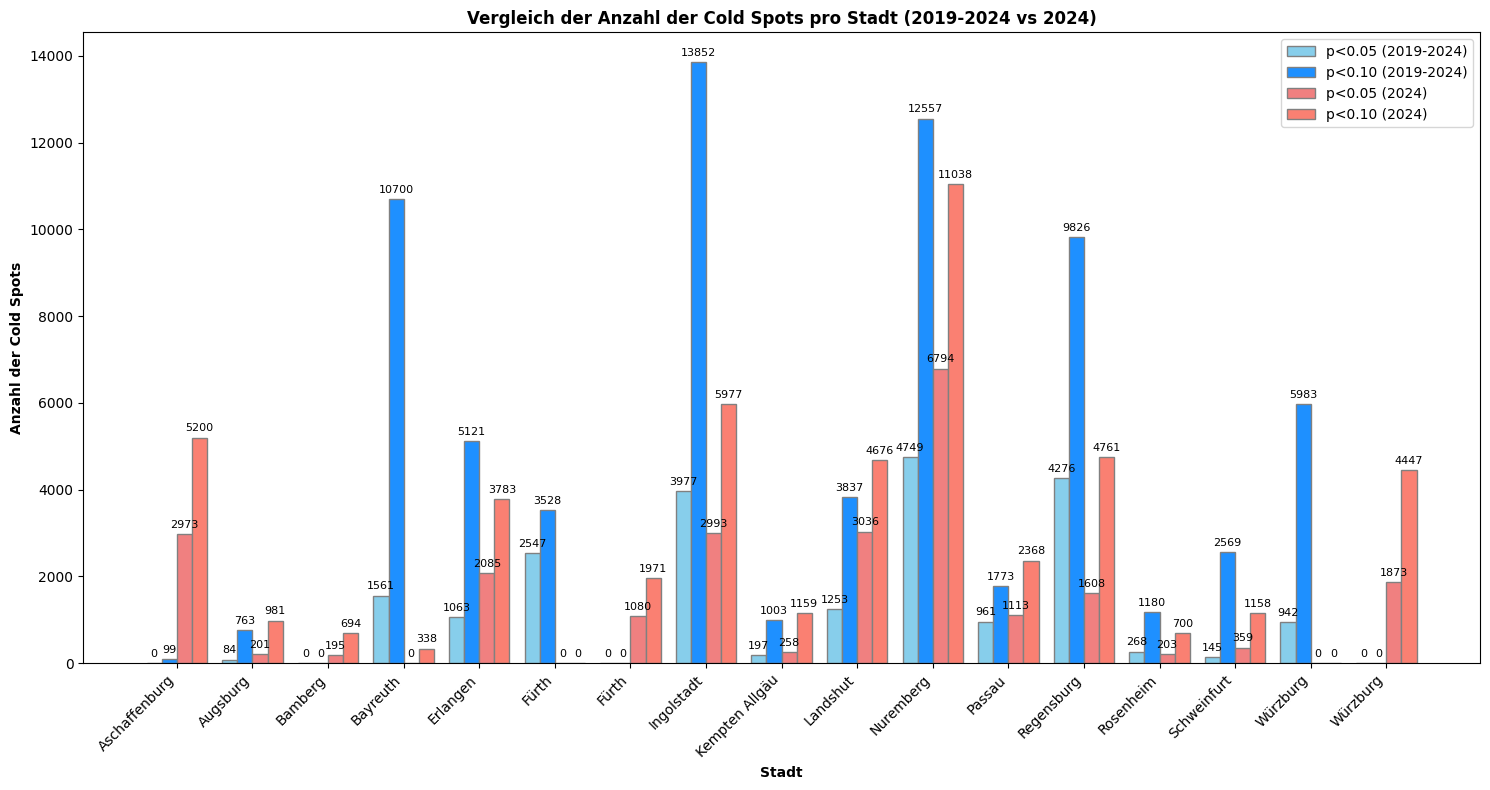

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure the summary dataframes exist
if 'cold_spot_summary_df' not in locals() or 'cold_spot_summary_df_2024' not in locals():
    print("Error: Summary dataframes not found. Please run the previous steps to create them.")
else:
    # Merge the two summary dataframes for comparison
    # Use an outer merge to include all cities from both dataframes
    comparison_df = pd.merge(
        cold_spot_summary_df[['Stadt', 'Anzahl Cold Spots (p<0.05)', 'Anzahl Cold Spots (p<0.10)']],
        cold_spot_summary_df_2024[['Stadt', 'Anzahl Cold Spots (p<0.05)', 'Anzahl Cold Spots (p<0.10)']],
        on='Stadt',
        how='outer',
        suffixes=('_2019_2024', '_2024')
    )

    # Fill NaN values with 0, which would occur for cities present in one period but not the other
    comparison_df.fillna(0, inplace=True)

    # Sort the DataFrame by city name for consistent plotting
    comparison_df.sort_values('Stadt', inplace=True)

    # Define the cities and the categories for plotting
    cities = comparison_df['Stadt']
    categories = ['p<0.05 (2019-2024)', 'p<0.10 (2019-2024)', 'p<0.05 (2024)', 'p<0.10 (2024)']

    # Define the data for the bars
    data = np.array([
        comparison_df['Anzahl Cold Spots (p<0.05)_2019_2024'].values,
        comparison_df['Anzahl Cold Spots (p<0.10)_2019_2024'].values,
        comparison_df['Anzahl Cold Spots (p<0.05)_2024'].values,
        comparison_df['Anzahl Cold Spots (p<0.10)_2024'].values
    ]).T # Transpose to get data per city

    # Set up the plot
    fig, ax = plt.subplots(figsize=(15, 8)) # Adjust figure size as needed

    bar_width = 0.2
    # Positions for the groups of bars on the x-axis
    r = np.arange(len(cities))

    # Create the grouped bars
    bar1 = ax.bar(r - 1.5*bar_width, data[:, 0], color='skyblue', width=bar_width, edgecolor='grey', label=categories[0])
    bar2 = ax.bar(r - 0.5*bar_width, data[:, 1], color='dodgerblue', width=bar_width, edgecolor='grey', label=categories[1])
    bar3 = ax.bar(r + 0.5*bar_width, data[:, 2], color='lightcoral', width=bar_width, edgecolor='grey', label=categories[2])
    bar4 = ax.bar(r + 1.5*bar_width, data[:, 3], color='salmon', width=bar_width, edgecolor='grey', label=categories[3])


    # Add labels, title and legend
    ax.set_xlabel('Stadt', fontweight='bold')
    ax.set_ylabel('Anzahl der Cold Spots', fontweight='bold')
    ax.set_title('Vergleich der Anzahl der Cold Spots pro Stadt (2019-2024 vs 2024)', fontweight='bold')
    ax.set_xticks(r)
    ax.set_xticklabels(cities, rotation=45, ha='right') # Rotate labels for better readability
    ax.legend()

    # Add count labels on top of the bars (optional)
    def autolabel(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate('{}'.format(int(height)),
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

    # Autolabel only if the number of cities is not too large to avoid clutter
    if len(cities) <= 20: # You can adjust this threshold
         autolabel(bar1)
         autolabel(bar2)
         autolabel(bar3)
         autolabel(bar4)


    # Adjust layout to prevent labels overlapping
    plt.tight_layout()

    # Display the plot
    plt.show()

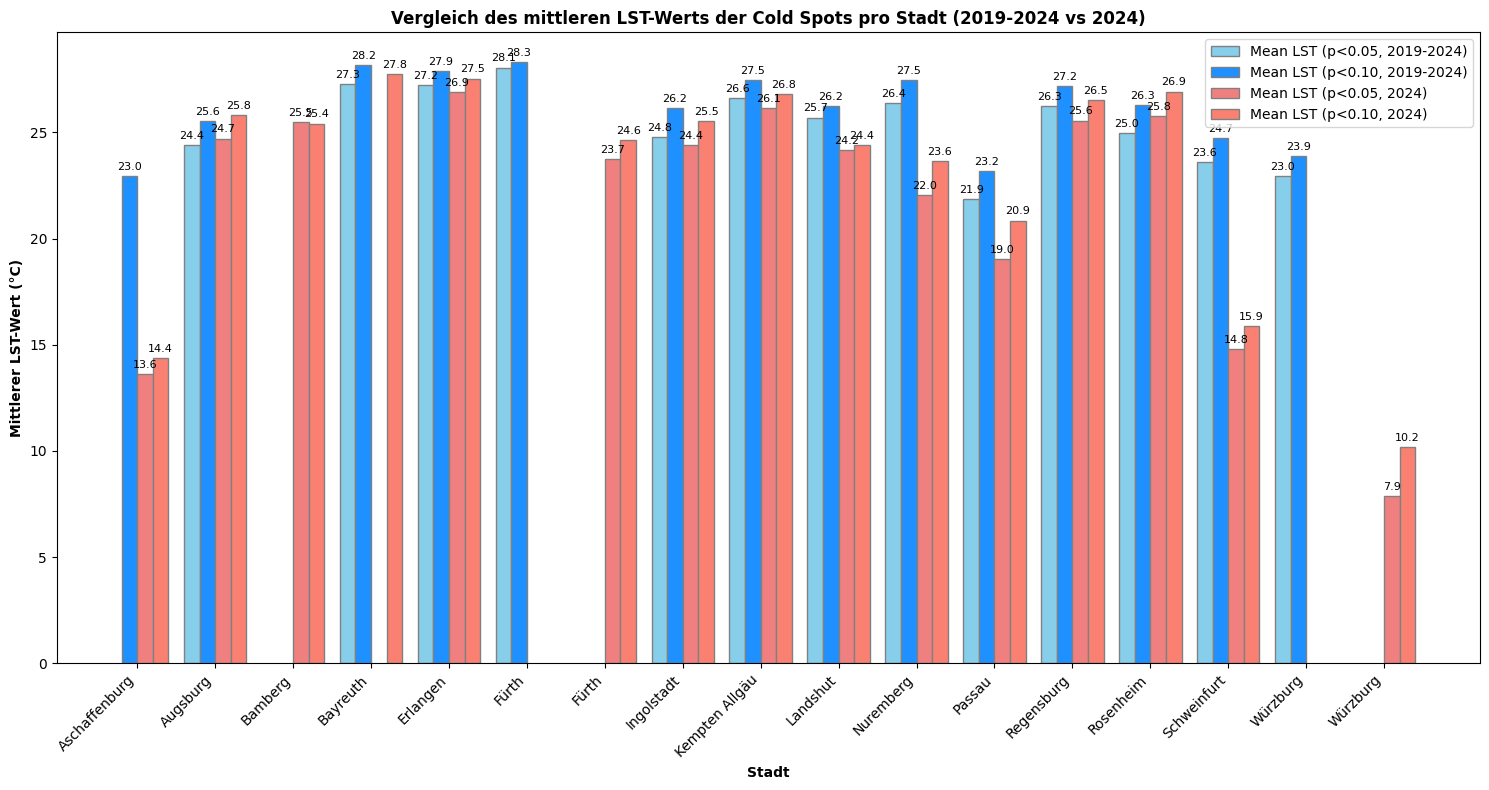

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure the summary dataframes exist
if 'cold_spot_summary_df' not in locals() or 'cold_spot_summary_df_2024' not in locals():
    print("Error: Summary dataframes not found. Please run the previous steps to create them.")
else:
    # Merge the two summary dataframes for comparison of Mean LST
    # Use an outer merge to include all cities from both dataframes
    comparison_mean_lst_df = pd.merge(
        cold_spot_summary_df[['Stadt', 'Mean LST (p<0.05)', 'Mean LST (p<0.10)']],
        cold_spot_summary_df_2024[['Stadt', 'Mean LST (p<0.05)', 'Mean LST (p<0.10)']],
        on='Stadt',
        how='outer',
        suffixes=('_2019_2024', '_2024')
    )

    # Fill NaN values with a value that can be visually distinguished or ignored, e.g., 0 or None
    # For plotting mean values, using NaN is often better as it won't plot a bar where no data exists.
    # However, for simplicity in this example, we'll fill with 0, but be aware this might misrepresent data absence.
    # A better approach for visual clarity with missing data might involve more complex plotting or data handling.
    comparison_mean_lst_df.fillna(np.nan, inplace=True) # Use NaN to indicate missing data

    # Sort the DataFrame by city name for consistent plotting
    comparison_mean_lst_df.sort_values('Stadt', inplace=True)

    # Define the cities and the categories for plotting
    cities = comparison_mean_lst_df['Stadt']
    categories = ['Mean LST (p<0.05, 2019-2024)', 'Mean LST (p<0.10, 2019-2024)', 'Mean LST (p<0.05, 2024)', 'Mean LST (p<0.10, 2024)']

    # Define the data for the bars (mean LST values)
    data_mean_lst = np.array([
        comparison_mean_lst_df['Mean LST (p<0.05)_2019_2024'].values,
        comparison_mean_lst_df['Mean LST (p<0.10)_2019_2024'].values,
        comparison_mean_lst_df['Mean LST (p<0.05)_2024'].values,
        comparison_mean_lst_df['Mean LST (p<0.10)_2024'].values
    ]).T # Transpose to get data per city

    # Set up the plot
    fig, ax = plt.subplots(figsize=(15, 8)) # Adjust figure size as needed

    bar_width = 0.2
    # Positions for the groups of bars on the x-axis
    r = np.arange(len(cities))

    # Create the grouped bars for Mean LST
    bar1_mean = ax.bar(r - 1.5*bar_width, data_mean_lst[:, 0], color='skyblue', width=bar_width, edgecolor='grey', label=categories[0])
    bar2_mean = ax.bar(r - 0.5*bar_width, data_mean_lst[:, 1], color='dodgerblue', width=bar_width, edgecolor='grey', label=categories[1])
    bar3_mean = ax.bar(r + 0.5*bar_width, data_mean_lst[:, 2], color='lightcoral', width=bar_width, edgecolor='grey', label=categories[2])
    bar4_mean = ax.bar(r + 1.5*bar_width, data_mean_lst[:, 3], color='salmon', width=bar_width, edgecolor='grey', label=categories[3])


    # Add labels, title and legend
    ax.set_xlabel('Stadt', fontweight='bold')
    ax.set_ylabel('Mittlerer LST-Wert (°C)', fontweight='bold')
    ax.set_title('Vergleich des mittleren LST-Werts der Cold Spots pro Stadt (2019-2024 vs 2024)', fontweight='bold')
    ax.set_xticks(r)
    ax.set_xticklabels(cities, rotation=45, ha='right') # Rotate labels for better readability
    ax.legend()

    # Add value labels on top of the bars (optional, only if not too many cities)
    def autolabel_mean(bars):
        for bar in bars:
            height = bar.get_height()
            # Only annotate if the height is not NaN (i.e., data exists)
            if not pd.isna(height):
                ax.annotate('{:.1f}'.format(height), # Format to 1 decimal place
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),  # 3 points vertical offset
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8)

    # Autolabel only if the number of cities is not too large to avoid clutter
    if len(cities) <= 20: # You can adjust this threshold
         autolabel_mean(bar1_mean)
         autolabel_mean(bar2_mean)
         autolabel_mean(bar3_mean)
         autolabel_mean(bar4_mean)


    # Adjust layout to prevent labels overlapping
    plt.tight_layout()

    # Display the plot
    plt.show()

==> Die Cold Spots waren im Gesamtzeitraum 2019-2024 tendenziell paar °C heißer, als im Jahr 2024

# alle Daten auf interaktiver Karte visualisieren

In [ ]:
import folium
import geopandas as gpd # Assuming geopandas is needed for any potential data handling, though Folium works with GeoJSON strings
import os # Needed for file path joining, though not directly used in the final map creation logic


# --- 1. Initialisierung der Karte ---
# Approximate center of Bavaria
bavaria_center = [48.7, 11.5]

# Create the map
m = folium.Map(location=bavaria_center, zoom_start=8)

# --- 2. Datenaufbereitung für Layer ---
# Define the target CRS for Folium (WGS84 is standard)
target_crs = "EPSG:4326"

# Reproject the 2024 cold spot data
reprojected_cold_spots_p005_2024 = {}
print("Reprojecting 2024 p<0.05 data...")
for city, gdf in loaded_cold_spots_p005.items():
    if gdf is not None and not gdf.empty:
        try:
            reprojected_cold_spots_p005_2024[city] = gdf.to_crs(target_crs)
            print(f"  Reprojected {city} (p<0.05, 2024).")
        except Exception as e:
            print(f"  Error reprojecting {city} (p<0.05, 2024): {e}")
    else:
         print(f"  Skipping reprojection for empty or missing {city} (p<0.05, 2024) data.")


reprojected_cold_spots_p010_2024 = {}
print("\nReprojecting 2024 p<0.10 data...")
for city, gdf in loaded_cold_spots_p010.items():
    if gdf is not None and not gdf.empty:
        try:
            reprojected_cold_spots_p010_2024[city] = gdf.to_crs(target_crs)
            print(f"  Reprojected {city} (p<0.10, 2024).")
        except Exception as e:
            print(f"  Error reprojecting {city} (p<0.10, 2024): {e}")
    else:
         print(f"  Skipping reprojection for empty or missing {city} (p<0.10, 2024) data.")


# Reproject the 2019-2024 cold spot data
reprojected_cold_spots_p005_2019_2024 = {}
print("\nReprojecting 2019-2024 p<0.05 data...")
for city_key, gdf in loaded_cold_spots_p005_2019_2024.items():
    if gdf is not None and not gdf.empty:
         # Extract cleaned city name from key for consistent dictionary keys
        city_name = city_key.replace("_cold_spots_2019-2024_p005.geojson", "").replace("_cold_spots_p005.geojson", "").replace("_", " ").replace(".geojson", "").replace("cold spots p005", "").strip()
        city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
        city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)")

        try:
            reprojected_cold_spots_p005_2019_2024[city_name] = gdf.to_crs(target_crs)
            print(f"  Reprojected {city_name} (p<0.05, 2019-2024).")
        except Exception as e:
            print(f"  Error reprojecting {city_name} (p<0.05, 2019-2024): {e}")
    else:
         # Extract cleaned city name from key for reporting
        city_name = city_key.replace("_cold_spots_2019-2024_p005.geojson", "").replace("_cold_spots_p005.geojson", "").replace("_", " ").replace(".geojson", "").replace("cold spots p005", "").strip()
        city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
        city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)")
        print(f"  Skipping reprojection for empty or missing {city_name} (p<0.05, 2019-2024) data.")


reprojected_cold_spots_p010_2019_2024 = {}
print("\nReprojecting 2019-2024 p<0.10 data...")
for city_key, gdf in loaded_cold_spots_p010_2019_2024.items():
    if gdf is not None and not gdf.empty:
         # Extract cleaned city name from key for consistent dictionary keys
        city_name = city_key.replace("_cold_spots_2019-2024_p010.geojson", "").replace("_cold_spots_p010.geojson", "").replace("_", " ").replace(".geojson", "").replace("cold spots p010", "").strip()
        city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
        city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)")

        try:
            reprojected_cold_spots_p010_2019_2024[city_name] = gdf.to_crs(target_crs)
            print(f"  Reprojected {city_name} (p<0.10, 2019-2024).")
        except Exception as e:
            print(f"  Error reprojecting {city_name} (p<0.10, 2019-2024): {e}")
    else:
         # Extract cleaned city name from key for reporting
        city_name = city_key.replace("_cold_spots_2019-2024_p010.geojson", "").replace("_cold_spots_p010.geojson", "").replace("_", " ").replace(".geojson", "").replace("cold spots p010", "").strip()
        city_name = city_name.replace("ae", "ä").replace("oe", "ö").replace("ue", "ü").replace("Ue", "Ü")
        city_name = city_name.replace("Kempten Allgaeu", "Kempten (Allgäu)")
        print(f"  Skipping reprojection for empty or missing {city_name} (p<0.10, 2019-2024) data.")


print("\nData reprojection complete.")


# --- 3. Erstellung von Layer-Gruppen pro Stadt ---
# Get the list of unique cities from the reprojected data
# Combine keys from all reprojected data dictionaries to ensure all cities are included
cities_for_mapping = set(reprojected_cold_spots_p005_2024.keys()).union(
    set(reprojected_cold_spots_p010_2024.keys()),
    set(reprojected_cold_spots_p005_2019_2024.keys()),
    set(reprojected_cold_spots_p010_2019_2024.keys())
)
cities_for_mapping = sorted(list(cities_for_mapping)) # Sort cities alphabetically

# Initialize a dictionary to store FeatureGroups for each city
city_layer_groups = {}

# Create a FeatureGroup for each city and add it to the map
for city in cities_for_mapping:
    # Create a FeatureGroup for the current city
    feature_group = folium.FeatureGroup(name=city)

    # Add the FeatureGroup to the map
    feature_group.add_to(m)

    # Store the FeatureGroup in the dictionary
    city_layer_groups[city] = feature_group
    print(f"Erstellt Layer-Gruppe für: {city}")

print("\nLayer-Gruppen für alle Städte erstellt.")


# --- 4. Erstellung von Layern pro Zeitraum und Signifikanzlevel ---
# Iterate through each city layer group
print("Erstelle Layer für jeden Zeitraum und jedes Signifikanzniveau pro Stadt...")
for city, feature_group in city_layer_groups.items():
    print(f"\nBearbeite Layer für Stadt: {city}")

    # --- Add 2024 Layers ---

    # Add 2024 p<0.05 layer
    if city in reprojected_cold_spots_p005_2024 and not reprojected_cold_spots_p005_2024[city].empty:
        geojson_2024_p005 = folium.GeoJson(
            reprojected_cold_spots_p005_2024[city].to_json(),
            name=f'{city} - 2024 (p<0.05)', # Include city name in layer name for clarity in LayerControl
            marker=folium.CircleMarker(radius=3, fill=True, fill_opacity=0.7, color='blue', fill_color='blue'),
            tooltip=folium.features.GeoJsonTooltip(fields=['avg_summer_LST_Celsius'], aliases=['Avg LST (°C):']),
            show=False # Initially hide these layers
        )
        geojson_2024_p005.add_to(feature_group)
        geojson_2024_p005.add_to(m) # Also add to the map object
        print(f"  Hinzugefügt: {city} - 2024 (p<0.05)")
    else:
        print(f"  Keine Daten für {city} - 2024 (p<0.05).")

    # Add 2024 p<0.10 layer
    if city in reprojected_cold_spots_p010_2024 and not reprojected_cold_spots_p010_2024[city].empty:
        geojson_2024_p010 = folium.GeoJson(
            reprojected_cold_spots_p010_2024[city].to_json(),
            name=f'{city} - 2024 (p<0.10)', # Include city name in layer name
            marker=folium.CircleMarker(radius=3, fill=True, fill_opacity=0.7, color='lightblue', fill_color='lightblue'),
             tooltip=folium.features.GeoJsonTooltip(fields=['avg_summer_LST_Celsius'], aliases=['Avg LST (°C):']),
            show=False # Initially hide these layers
        )
        geojson_2024_p010.add_to(feature_group)
        geojson_2024_p010.add_to(m) # Also add to the map object
        print(f"  Hinzugefügt: {city} - 2024 (p<0.10)")
    else:
        print(f"  Keine Daten für {city} - 2024 (p<0.10).")


    # --- Add 2019-2024 Layers ---

    # Add 2019-2024 p<0.05 layer
    if city in reprojected_cold_spots_p005_2019_2024 and not reprojected_cold_spots_p005_2019_2024[city].empty:
         # Need to ensure the correct key is used to retrieve data from the dictionary
        geojson_2019_2024_p005 = folium.GeoJson(
            reprojected_cold_spots_p005_2019_2024[city].to_json(),
            name=f'{city} - 2019-2024 (p<0.05)', # Include city name in layer name
            marker=folium.CircleMarker(radius=3, fill=True, fill_opacity=0.7, color='darkred', fill_color='darkred'),
             tooltip=folium.features.GeoJsonTooltip(fields=['avg_summer_LST_Celsius'], aliases=['Avg LST (°C):']),
            show=False # Initially hide these layers
        )
        geojson_2019_2024_p005.add_to(feature_group)
        geojson_2019_2024_p005.add_to(m) # Also add to the map object
        print(f"  Hinzugefügt: {city} - 2019-2024 (p<0.05)")
    else:
        print(f"  Keine Daten für {city} - 2019-2024 (p<0.05).")


    # Add 2019-2024 p<0.10 layer
    if city in reprojected_cold_spots_p010_2019_2024 and not reprojected_cold_spots_p010_2019_2024[city].empty:
         # Need to ensure the correct key is used to retrieve data from the dictionary
        geojson_2019_2024_p010 = folium.GeoJson(
            reprojected_cold_spots_p010_2019_2024[city].to_json(),
            name=f'{city} - 2019-2024 (p<0.10)', # Include city name in layer name
            marker=folium.CircleMarker(radius=3, fill=True, fill_opacity=0.7, color='salmon', fill_color='salmon'),
            tooltip=folium.features.GeoJsonTooltip(fields=['avg_summer_LST_Celsius'], aliases=['Avg LST (°C):']),
            show=False # Initially hide these layers
        )
        geojson_2019_2024_p010.add_to(feature_group)
        geojson_2019_2024_p010.add_to(m) # Also add to the map object
        print(f"  Hinzugefügt: {city} - 2019-2024 (p<0.10)")
    else:
        print(f"  Keine Daten für {city} - 2019-2024 (p<0.10).")


print("\nErstellung der Layer pro Stadt, Zeitraum und Signifikanzniveau abgeschlossen.")


# --- 5. Hinzufügen der Layer und Layer-Kontrolle ---
# Add the LayerControl to the map
# This will automatically include all FeatureGroups and individual layers that have been added to the map 'm'
folium.LayerControl().add_to(m)

print("Layer-Kontrolle zur Karte hinzugefügt.")

#m ==> wenn Karte geladen ist kann Notebook nichtmehr gespeichert werden, also vor dem Speichern einfach #

Reprojecting 2024 p<0.05 data...
  Reprojected Aschaffenburg (p<0.05, 2024).
  Reprojected Augsburg (p<0.05, 2024).
  Reprojected Bamberg (p<0.05, 2024).
  Reprojected Erlangen (p<0.05, 2024).
  Reprojected Ingolstadt (p<0.05, 2024).
  Reprojected Landshut (p<0.05, 2024).
  Reprojected Nuremberg (p<0.05, 2024).
  Reprojected Passau (p<0.05, 2024).
  Reprojected Regensburg (p<0.05, 2024).
  Reprojected Rosenheim (p<0.05, 2024).
  Reprojected Schweinfurt (p<0.05, 2024).
  Reprojected Fürth (p<0.05, 2024).
  Reprojected Würzburg (p<0.05, 2024).
  Reprojected Kempten Allgäu (p<0.05, 2024).

Reprojecting 2024 p<0.10 data...
  Reprojected Aschaffenburg (p<0.10, 2024).
  Reprojected Augsburg (p<0.10, 2024).
  Reprojected Bamberg (p<0.10, 2024).
  Reprojected Bayreuth (p<0.10, 2024).
  Reprojected Erlangen (p<0.10, 2024).
  Reprojected Ingolstadt (p<0.10, 2024).
  Reprojected Landshut (p<0.10, 2024).
  Reprojected Nuremberg (p<0.10, 2024).
  Reprojected Passau (p<0.10, 2024).
  Reprojected Reg